## Importing the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tracks = pd.read_csv("fma_metadata/tracks.csv", header=[0,1], index_col=0)
features = pd.read_csv("fma_metadata/features.csv", header=[0,1,2], index_col=0)
genres = pd.read_csv("fma_metadata/genres.csv")
echonest = pd.read_csv("fma_metadata/echonest.csv", index_col=0)

In [3]:
print("Tracks:", tracks.shape)
print("Features:", features.shape)
print("Genres:", genres.shape)
print("Echonest:", echonest.shape)

Tracks: (106574, 52)
Features: (106574, 518)
Genres: (163, 5)
Echonest: (13132, 249)


In [15]:
tracks.columns = tracks.columns.str.replace('_', '')
features.columns = features.columns.str.replace('_', '')
print(tracks.columns)
tracks.head()

Index(['albumcomments', 'albumdatecreated', 'albumdatereleased',
       'albumengineer', 'albumfavorites', 'albumid', 'albuminformation',
       'albumlistens', 'albumproducer', 'albumtags', 'albumtitle',
       'albumtracks', 'albumtype', 'artistactiveyearbegin',
       'artistactiveyearend', 'artistassociatedlabels', 'artistbio',
       'artistcomments', 'artistdatecreated', 'artistfavorites', 'artistid',
       'artistlatitude', 'artistlocation', 'artistlongitude', 'artistmembers',
       'artistname', 'artistrelatedprojects', 'artisttags', 'artistwebsite',
       'artistwikipediapage', 'setsplit', 'setsubset', 'trackbitrate',
       'trackcomments', 'trackcomposer', 'trackdatecreated',
       'trackdaterecorded', 'trackduration', 'trackfavorites', 'trackgenretop',
       'trackgenres', 'trackgenresall', 'trackinformation', 'trackinterest',
       'tracklanguagecode', 'tracklicense', 'tracklistens', 'tracklyricist',
       'tracknumber', 'trackpublisher', 'tracktags', 'tracktitle'],

,albumcomments,albumdatecreated,albumdatereleased,albumengineer,albumfavorites,albumid,albuminformation,albumlistens,albumproducer,albumtags,...,trackinformation,trackinterest,tracklanguagecode,tracklicense,tracklistens,tracklyricist,tracknumber,trackpublisher,tracktags,tracktitle
track_id,,,,,,,,,,,,,,,,,,,,,
2,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,[],...,NaN,4656,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1293,NaN,3,NaN,[],Food
3,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,[],...,NaN,1470,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,514,NaN,4,NaN,[],Electric Ave
5,0,2008-11-26 01:44:45,2009-01-05 00:00:00,NaN,4,1,<p></p>,6073,NaN,[],...,NaN,1933,en,Attribution-NonCommercial-ShareAlike 3.0 Inter...,1151,NaN,6,NaN,[],This World
10,0,2008-11-26 01:45:08,2008-02-06 00:00:00,NaN,4,6,NaN,47632,NaN,[],...,NaN,54881,en,Attribution-NonCommercial-NoDerivatives (aka M...,50135,NaN,1,NaN,[],Freeway
20,0,2008-11-26 01:45:05,2009-01-06 00:00:00,NaN,2,4,"<p> ""spiritual songs"" from Nicky Cook</p>",2710,NaN,[],...,NaN,978,en,Attribution-NonCommercial-NoDerivatives (aka M...,361,NaN,3,NaN,[],Spiritual Level


In [18]:
small_tracks = tracks[tracks['setsubset'] == 'small']
labels = small_tracks['trackgenretop']
valid_idx = labels.dropna().index
labels = labels.loc[valid_idx]

In [19]:
X = features.loc[valid_idx]
y = labels
print(X.shape)
print(y.shape)

(8000, 518)
(8000,)


## Encode genre labels

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Genres:", le.classes_)
X = X.fillna(X.mean())

Genres: ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape, X_test.shape)

(6400, 518) (1600, 518)


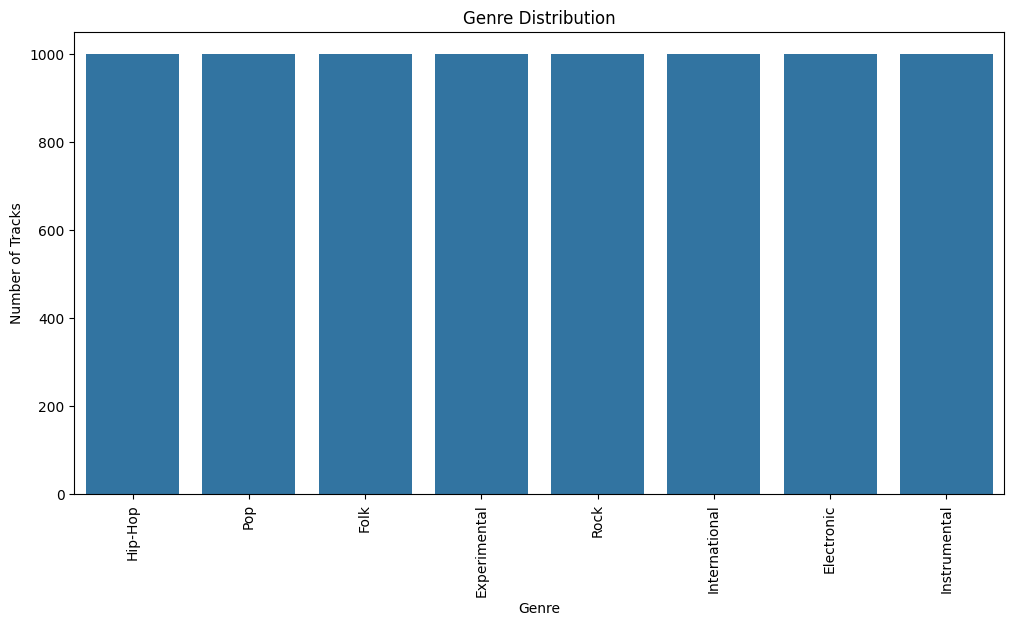

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

genre_counts = labels.value_counts()

sns.barplot(
    x=genre_counts.index,
    y=genre_counts.values
)

plt.xticks(rotation=90)
plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.show()

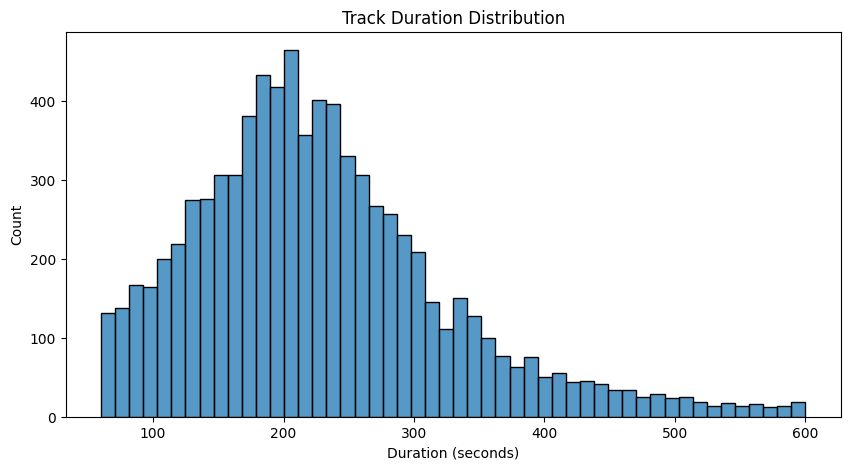

In [26]:
plt.figure(figsize=(10,5))

duration = small_tracks.loc[valid_idx]['trackduration']

sns.histplot(duration, bins=50)

plt.title("Track Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

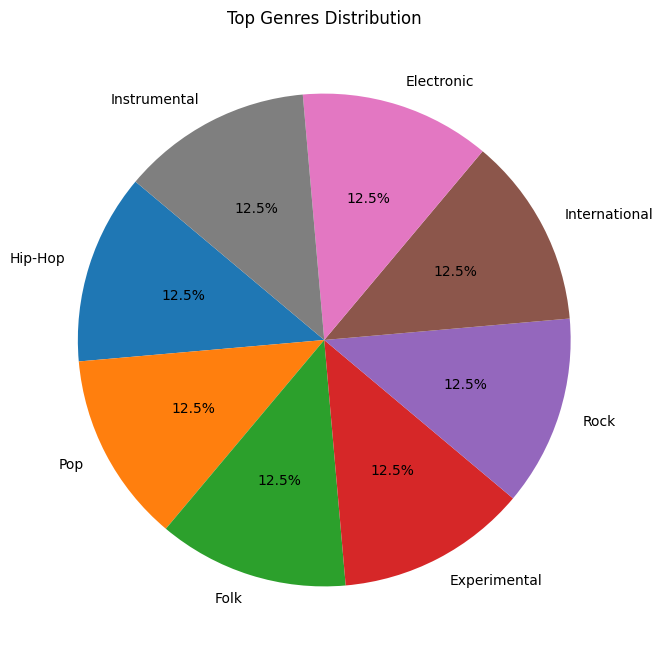

In [27]:
plt.figure(figsize=(8,8))

genre_counts.head(8).plot.pie(
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Top Genres Distribution")
plt.ylabel("")
plt.show()

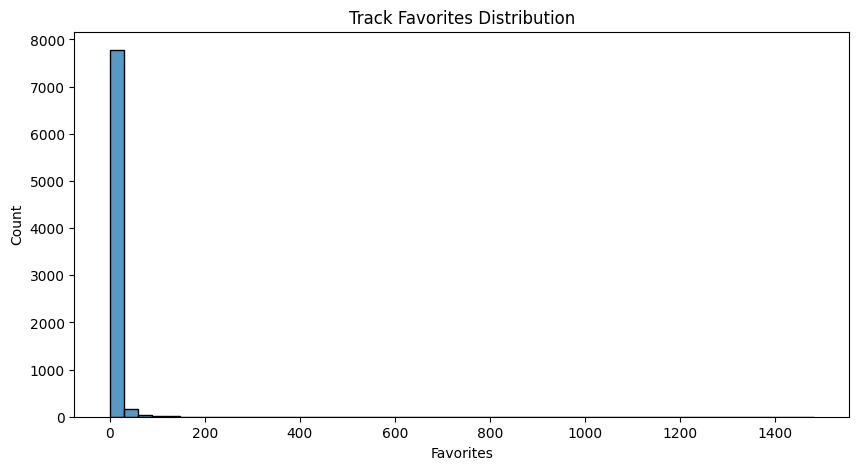

In [28]:
plt.figure(figsize=(10,5))

favorites = small_tracks.loc[valid_idx]['trackfavorites']

sns.histplot(favorites, bins=50)

plt.title("Track Favorites Distribution")
plt.xlabel("Favorites")
plt.ylabel("Count")
plt.show()

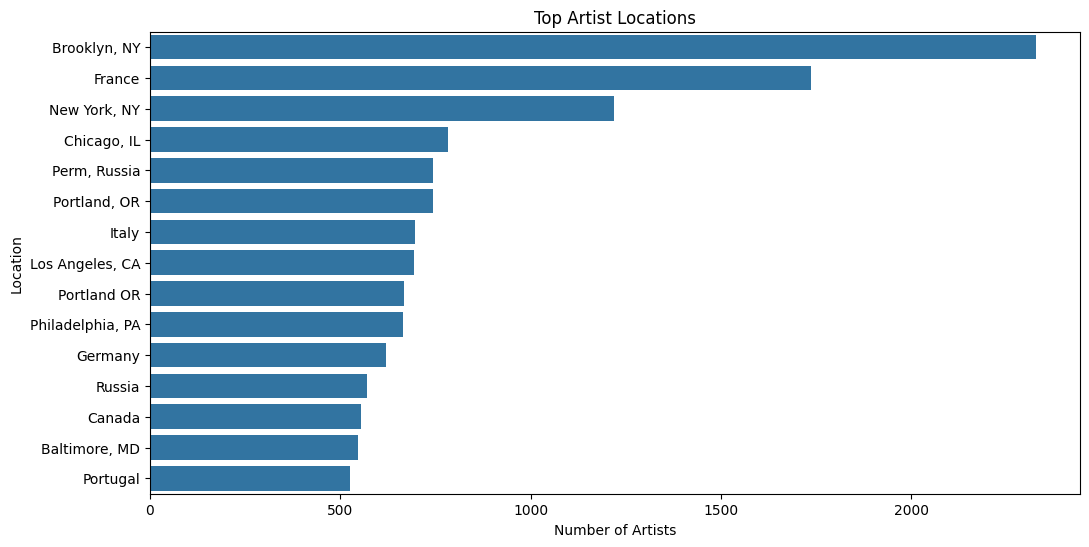

In [29]:
plt.figure(figsize=(12,6))

location_counts = tracks['artistlocation'].value_counts().head(15)

sns.barplot(
    x=location_counts.values,
    y=location_counts.index
)

plt.title("Top Artist Locations")
plt.xlabel("Number of Artists")
plt.ylabel("Location")
plt.show()

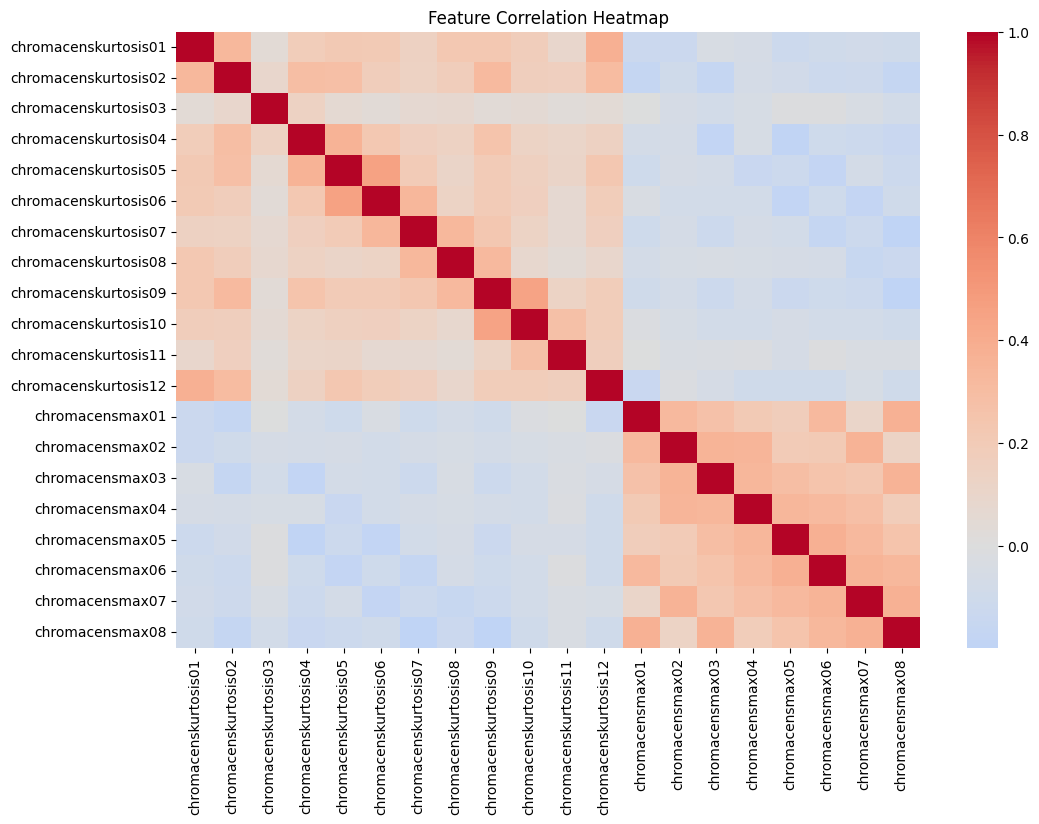

In [30]:
numeric_features = X.select_dtypes(include=['float64','int64'])

corr = numeric_features.iloc[:, :20].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

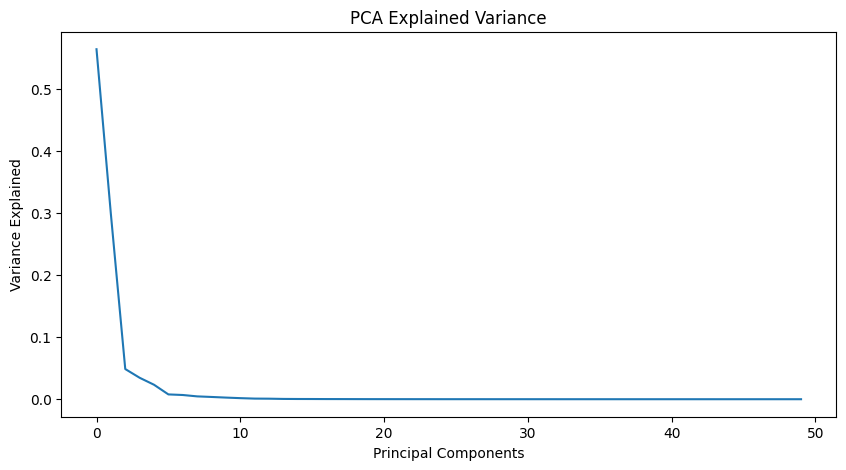

In [31]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X)

plt.figure(figsize=(10,5))

plt.plot(pca.explained_variance_ratio_[:50])

plt.title("PCA Explained Variance")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.show()

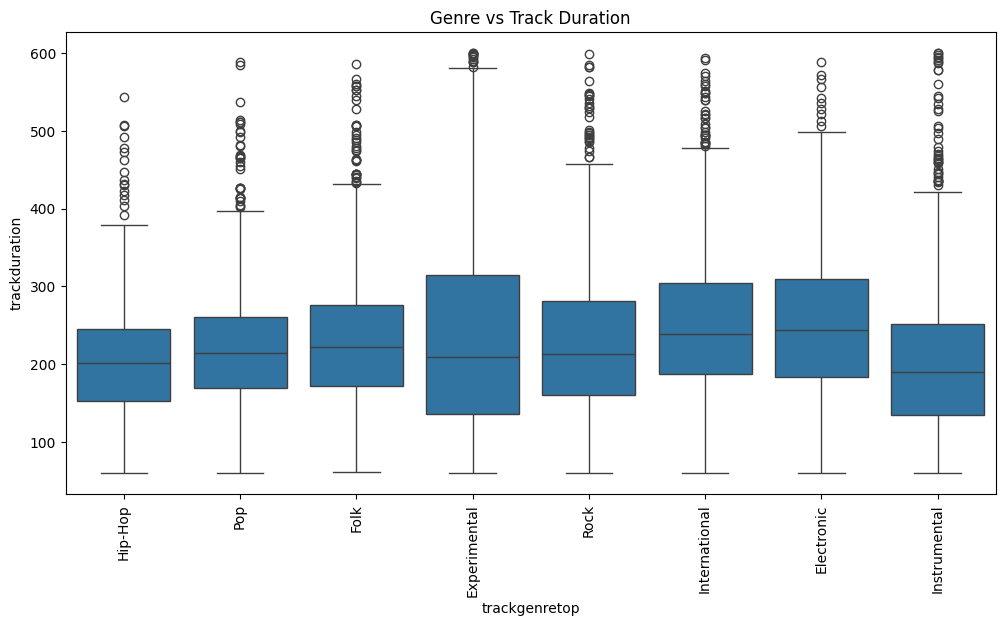

In [32]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=labels,
    y=duration
)

plt.xticks(rotation=90)
plt.title("Genre vs Track Duration")
plt.show()

In [33]:
print("Total tracks:", len(tracks))
print("Tracks in small dataset:", len(small_tracks))
print("Tracks with genre labels:", len(labels))
print("Number of features:", X.shape[1])

Total tracks: 106574
Tracks in small dataset: 8000
Tracks with genre labels: 8000
Number of features: 518
